In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind,f_oneway,chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import r2_score,mean_squared_error,accuracy_score,classification_report
import warnings
import joblib

In [6]:
warnings.filterwarnings('ignore')


plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline
print("All libraries imported successfully!")


All libraries imported successfully!


In [7]:
df=pd.read_csv(r'C:\\Users\\ABISHEK\\OneDrive\\Desktop\\AIML\\student_performance.csv')
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (14003, 16)


,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
0,19,64,1,0,0,1,0,19,2,8,1,59,40,0,1,3
1,19,64,1,0,0,1,0,23,3,16,0,90,66,0,1,2
2,19,64,1,0,0,1,0,28,1,19,0,67,99,1,1,0
3,19,64,1,1,0,1,0,19,2,8,1,59,40,0,1,3
4,19,64,1,1,0,1,0,23,3,16,0,90,66,0,1,2


In [8]:
df.shape

(14003, 16)

In [9]:
df.columns

Index(['StudyHours', 'Attendance', 'Resources', 'Extracurricular',
       'Motivation', 'Internet', 'Gender', 'Age', 'LearningStyle',
       'OnlineCourses', 'Discussions', 'AssignmentCompletion', 'ExamScore',
       'EduTech', 'StressLevel', 'FinalGrade'],
      dtype='object')

In [10]:
df.info

<bound method DataFrame.info of        StudyHours  Attendance  Resources  Extracurricular  Motivation  \
0              19          64          1                0           0   
1              19          64          1                0           0   
2              19          64          1                0           0   
3              19          64          1                1           0   
4              19          64          1                1           0   
...           ...         ...        ...              ...         ...   
13998          30          62          0                1           1   
13999          30          62          0                1           1   
14000          22          90          2                0           1   
14001          22          90          2                0           1   
14002          10          86          2                1           2   

       Internet  Gender  Age  LearningStyle  OnlineCourses  Discussions  \
0             1 

In [11]:
df.describe()


,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
count,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.00000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000
mean,19.987431,80.194316,1.104406,0.594158,0.905806,0.925516,0.551953,23.532172,1.515461,9.891952,0.60587,74.502535,70.346926,0.709062,1.304363,1.447904
std,5.890637,11.472181,0.697362,0.491072,0.695896,0.262566,0.497311,3.514293,1.112941,6.112801,0.48868,14.632177,17.688113,0.454211,0.785383,1.121550
min,5.000000,60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000,0.000000,0.000000,0.00000,50.000000,40.000000,0.000000,0.000000,0.000000
25%,16.000000,70.000000,1.000000,0.000000,0.000000,1.000000,0.000000,20.000000,1.000000,5.000000,0.00000,62.000000,55.000000,0.000000,1.000000,0.000000
50%,20.000000,80.000000,1.000000,1.000000,1.000000,1.000000,1.000000,24.000000,2.000000,10.000000,1.00000,74.000000,70.000000,1.000000,2.000000,1.000000
75%,24.000000,90.000000,2.000000,1.000000,1.000000,1.000000,1.000000,27.000000,3.000000,15.000000,1.00000,87.000000,86.000000,1.000000,2.000000,2.000000
max,44.000000,100.000000,2.000000,1.000000,2.000000,1.000000,1.000000,29.000000,3.000000,20.000000,1.00000,100.000000,100.000000,1.000000,2.000000,3.000000


In [12]:
df.isnull().sum()

StudyHours              0
Attendance              0
Resources               0
Extracurricular         0
Motivation              0
Internet                0
Gender                  0
Age                     0
LearningStyle           0
OnlineCourses           0
Discussions             0
AssignmentCompletion    0
ExamScore               0
EduTech                 0
StressLevel             0
FinalGrade              0
dtype: int64

In [13]:
df.isnull().sum()/len(df)*100

StudyHours              0.0
Attendance              0.0
Resources               0.0
Extracurricular         0.0
Motivation              0.0
Internet                0.0
Gender                  0.0
Age                     0.0
LearningStyle           0.0
OnlineCourses           0.0
Discussions             0.0
AssignmentCompletion    0.0
ExamScore               0.0
EduTech                 0.0
StressLevel             0.0
FinalGrade              0.0
dtype: float64

In [14]:
print("=== Data Informatiion ===")
print(df.info())
print("\n=== Missing Values ===")
print(df.isnull().sum())
df["Gender"] = df["Gender"].fillna("Unknown")
print("Missing values in Gender filled with 'Unknown'")

=== Data Informatiion ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14003 entries, 0 to 14002
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   StudyHours            14003 non-null  int64
 1   Attendance            14003 non-null  int64
 2   Resources             14003 non-null  int64
 3   Extracurricular       14003 non-null  int64
 4   Motivation            14003 non-null  int64
 5   Internet              14003 non-null  int64
 6   Gender                14003 non-null  int64
 7   Age                   14003 non-null  int64
 8   LearningStyle         14003 non-null  int64
 9   OnlineCourses         14003 non-null  int64
 10  Discussions           14003 non-null  int64
 11  AssignmentCompletion  14003 non-null  int64
 12  ExamScore             14003 non-null  int64
 13  EduTech               14003 non-null  int64
 14  StressLevel           14003 non-null  int64
 15  FinalGrade            14003

In [15]:
def descriptive_stats(data):
    if isinstance(data,pd.Series):
        data=data.values
    stats_dict={
            'count': len(data),
            'mean': np.mean(data),
            'median':np.median(data),
            'std':np.std(data,ddof=1),
            'min':np.min(data),
            'max':np.max(data),
            'q1':np.percentile(data,25),
            'q3':np.percentile(data,75),
            'iqr': np.percentile(data,75)-np.percentile(data,25),
            'skewness': stats.skew(data),
            'kurtosis': stats.kurtosis(data)
    }
    return pd.Series(stats_dict)


print("Descriptive Statistics for ExamScore:")
print(descriptive_stats(df['ExamScore']))


df.describe()

Descriptive Statistics for ExamScore:
count       14003.000000
mean           70.346926
median         70.000000
std            17.688113
min            40.000000
max           100.000000
q1             55.000000
q3             86.000000
iqr            31.000000
skewness       -0.017949
kurtosis       -1.208528
dtype: float64


,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
count,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000,14003.00000,14003.000000,14003.000000,14003.000000,14003.000000,14003.000000
mean,19.987431,80.194316,1.104406,0.594158,0.905806,0.925516,0.551953,23.532172,1.515461,9.891952,0.60587,74.502535,70.346926,0.709062,1.304363,1.447904
std,5.890637,11.472181,0.697362,0.491072,0.695896,0.262566,0.497311,3.514293,1.112941,6.112801,0.48868,14.632177,17.688113,0.454211,0.785383,1.121550
min,5.000000,60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000,0.000000,0.000000,0.00000,50.000000,40.000000,0.000000,0.000000,0.000000
25%,16.000000,70.000000,1.000000,0.000000,0.000000,1.000000,0.000000,20.000000,1.000000,5.000000,0.00000,62.000000,55.000000,0.000000,1.000000,0.000000
50%,20.000000,80.000000,1.000000,1.000000,1.000000,1.000000,1.000000,24.000000,2.000000,10.000000,1.00000,74.000000,70.000000,1.000000,2.000000,1.000000
75%,24.000000,90.000000,2.000000,1.000000,1.000000,1.000000,1.000000,27.000000,3.000000,15.000000,1.00000,87.000000,86.000000,1.000000,2.000000,2.000000
max,44.000000,100.000000,2.000000,1.000000,2.000000,1.000000,1.000000,29.000000,3.000000,20.000000,1.00000,100.000000,100.000000,1.000000,2.000000,3.000000


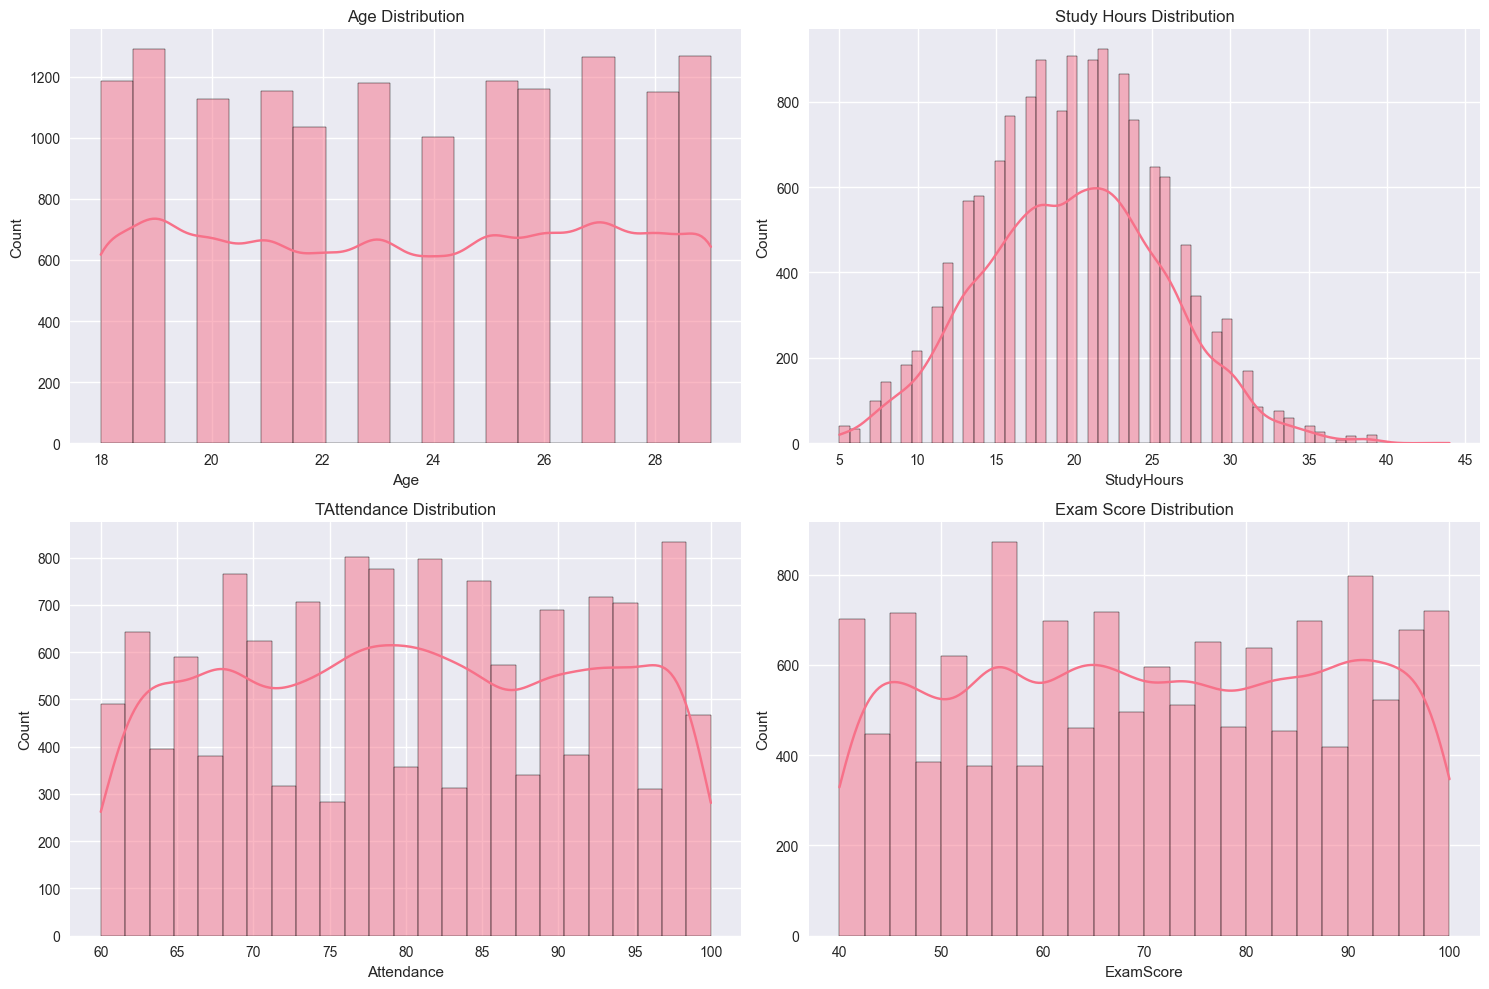

In [16]:
fig,axes=plt.subplots(2,2,figsize=(15,10))
sns.histplot(df['Age'],kde=True,ax=axes[0,0]).set_title('Age Distribution')
sns.histplot(df['StudyHours'],kde=True,ax=axes[0,1]).set_title('Study Hours Distribution')
sns.histplot(df['Attendance'],kde=True,ax=axes[1,0]).set_title('TAttendance Distribution')
sns.histplot(df['ExamScore'],kde=True,ax=axes[1,1]).set_title('Exam Score Distribution')
plt.tight_layout()
plt.show()

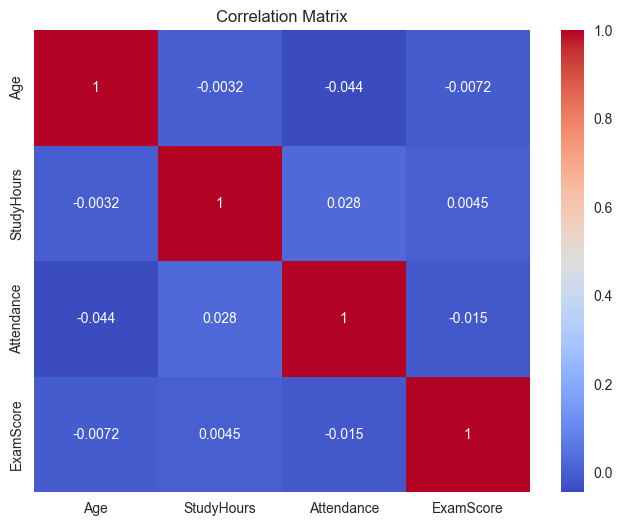

In [17]:
plt.figure(figsize=(8,6))
numeric_df = df[['Age', 'StudyHours', 'Attendance', 'ExamScore']]
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [18]:
from scipy.stats import ttest_ind
print("=== 1. T-Test : ExamScore by Gender ===")
male_score = df[df['Gender'] == 0]['ExamScore']
female_score = df[df['Gender'] == 1]['ExamScore']
t_stat, p_val = ttest_ind(male_score, female_score)
print(f"T-statistic: {t_stat:.4f}, p-value: {p_val:.4f}")

=== 1. T-Test : ExamScore by Gender ===
T-statistic: -2.5258, p-value: 0.0116


In [19]:
from scipy.stats import f_oneway
print("\n=== 2. ANOVA: ExamScore by LearningStyle ===")
groups = [group['ExamScore'].values for name, group in df.groupby('LearningStyle')]
f_stat, p_val = f_oneway(*groups)
print(f"F-statistic: {f_stat:.4f}, p-value: {p_val:.4f}")


=== 2. ANOVA: ExamScore by LearningStyle ===
F-statistic: 3.4795, p-value: 0.0152


In [20]:
from scipy.stats import chi2_contingency
print("\n=== 3. Chi-Square Test ===")
contingency = pd.crosstab(df['Gender'], df['LearningStyle'])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"Chi-square Statistic: {chi2:.4f}, P-value: {p:.4f}")


=== 3. Chi-Square Test ===
Chi-square Statistic: 17.4755, P-value: 0.0006


In [21]:
X = pd.get_dummies(df.drop(['ExamScore'], axis=1), drop_first=True)
y = df['ExamScore']
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)
reg_model = LinearRegression()
reg_model.fit(X_train, y_train)
y_pred = reg_model.predict(X_test)

In [22]:
print("=== Regression Results ===")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

=== Regression Results ===
R² Score: 0.9402
RMSE: 4.36


In [23]:
joblib.dump(reg_model, 'exam_score_model.pkl')
print("Model saved as 'exam_score_model.pkl'")

Model saved as 'exam_score_model.pkl'


In [24]:
X= pd.get_dummies(df.drop(['FinalGrade'], axis=1), drop_first=True)
y = df['FinalGrade']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

clf_model = RandomForestClassifier(n_estimators=100, random_state=42)

clf_model.fit(X_train, y_train)

y_pred = clf_model.predict(X_test)

print("=== Classification Results ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

joblib.dump(clf_model, 'final_grade_classifier_model.pkl')

print("✅ Model saved as 'final_grade_classifier_model.pkl'")

=== Classification Results ===
Accuracy: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       785
           1       1.00      1.00      1.00       647
           2       1.00      1.00      1.00       702
           3       1.00      1.00      1.00       667

    accuracy                           1.00      2801
   macro avg       1.00      1.00      1.00      2801
weighted avg       1.00      1.00      1.00      2801

✅ Model saved as 'final_grade_classifier_model.pkl'
